# Carga y visualización de ECG - sujeto único

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [2]:
# Configuración
SIGNALS_DIR = Path(r"C:\Users\USER\Downloads\ECGData\ECGData")
DIAGNOSTICS_PATH = Path(r"C:\Users\USER\Downloads\Diagnostics.xlsx")
FILENAME = "MUSE_20180113_134825_04000.csv" 
FS = 500  # Hz

LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

## Metadata del sujeto

In [3]:
diagnostics = pd.read_excel(DIAGNOSTICS_PATH)
subject_meta = diagnostics[diagnostics["FileName"] == Path(FILENAME).stem]

subject_meta = subject_meta.reset_index(drop=True)
subject_meta

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\USER\\Downloads\\Diagnostics.xlsx'

## Señal ECG

In [ ]:
signal_path = SIGNALS_DIR / FILENAME
ecg_signal = pd.read_csv(signal_path, header=None, names=LEADS)

n_samples = len(ecg_signal)
t = np.arange(n_samples) / FS

ecg_signal.head()

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
1,-39.04,-53.68,-14.64,48.8,-14.64,-34.16,-4.88,-175.68,-156.16,-102.48,-48.8,-29.28
2,-48.8,-58.56,-9.76,53.68,-19.52,-34.16,-9.76,-170.8,-151.28,-97.6,-48.8,-24.4
3,-48.8,-63.44,-14.64,58.56,-19.52,-39.04,-4.88,-165.92,-146.4,-92.72,-43.92,-19.52
4,-48.8,-63.44,-14.64,58.56,-19.52,-39.04,-4.88,-165.92,-141.52,-92.72,-43.92,-14.64


## Visualización

In [ ]:
rhythm = subject_meta.loc[0, "Rhythm"]
beat = subject_meta.loc[0, "Beat"]
age = subject_meta.loc[0, "PatientAge"]
gender = subject_meta.loc[0, "Gender"]

Text(0.5, 0.98, 'Sujeto: MUSE_20180113_134825_04000.csv | Rhythm: SB | Beat: 1AVB | Edad: 54 | Género: MALE')

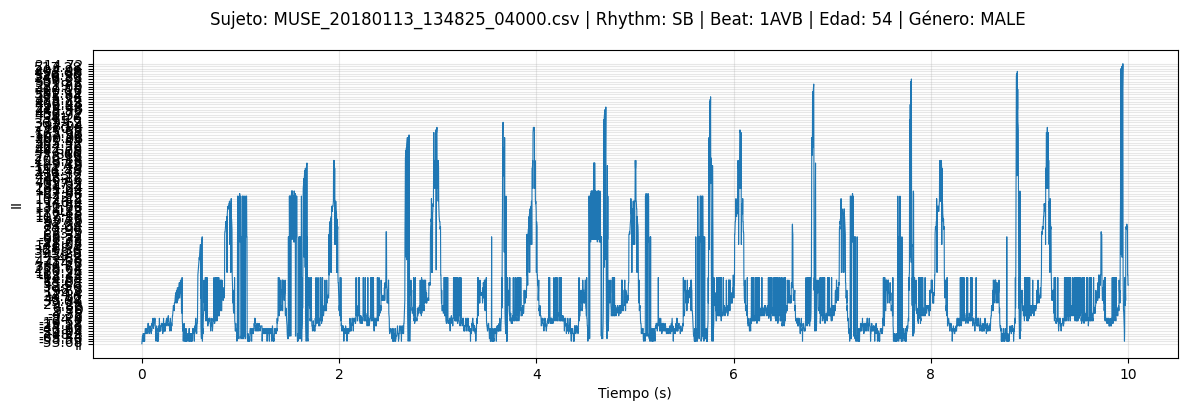

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(t, ecg_signal["II"], linewidth=0.8)
plt.ylabel("II")
plt.xlabel("Tiempo (s)")
plt.grid(True, alpha=0.3)

plt.suptitle(
    f"Sujeto: {FILENAME} | Rhythm: {rhythm} | Beat: {beat} | "
    f"Edad: {age} | Género: {gender}",
    fontsize=12
)

## SIN RUIDO

In [ ]:
SIGNALS_DIR_DENOISED = Path(r"C:\Users\USER\Downloads\ECGDataDenoised\ECGDataDenoised")

In [ ]:
subject_meta_denoised = diagnostics[diagnostics["FileName"] == Path(FILENAME).stem]

subject_meta_denoised = subject_meta_denoised.reset_index(drop=True)
subject_meta_denoised

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_134825_04000,SB,1AVB,54,MALE,58,58,102,432,424,2,60,10,211,262,427


In [ ]:
signal_path_denoised = SIGNALS_DIR_DENOISED / FILENAME
ecg_signal_denoised = pd.read_csv(signal_path_denoised, header=None, names=LEADS)

n_samples_denoised = len(ecg_signal_denoised)
t_denoised = np.arange(n_samples_denoised) / FS

ecg_signal_denoised.head()

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,-21.254,-9.747,6.5147,14.702,-11.715,0.83850,-4.9594,-74.985,-97.431,-57.378,-48.776,-39.156
1,-25.321,-12.598,7.7595,17.888,-14.003,-0.27525,-5.3779,-71.346,-92.629,-54.019,-46.025,-34.036
2,-28.429,-14.603,8.8907,20.150,-15.836,-1.05100,-5.7574,-68.086,-88.802,-51.590,-43.740,-29.764
3,-29.967,-15.258,9.8015,20.917,-16.907,-1.28860,-6.0736,-65.333,-86.470,-50.598,-42.359,-27.019
4,-29.903,-14.663,10.3600,20.238,-17.152,-1.05810,-6.3205,-62.947,-85.532,-50.950,-42.203,-26.129


Text(0.5, 0.98, 'Sujeto: MUSE_20180113_134825_04000.csv | Rhythm: SB | Beat: 1AVB | Edad: 54 | Género: MALE')

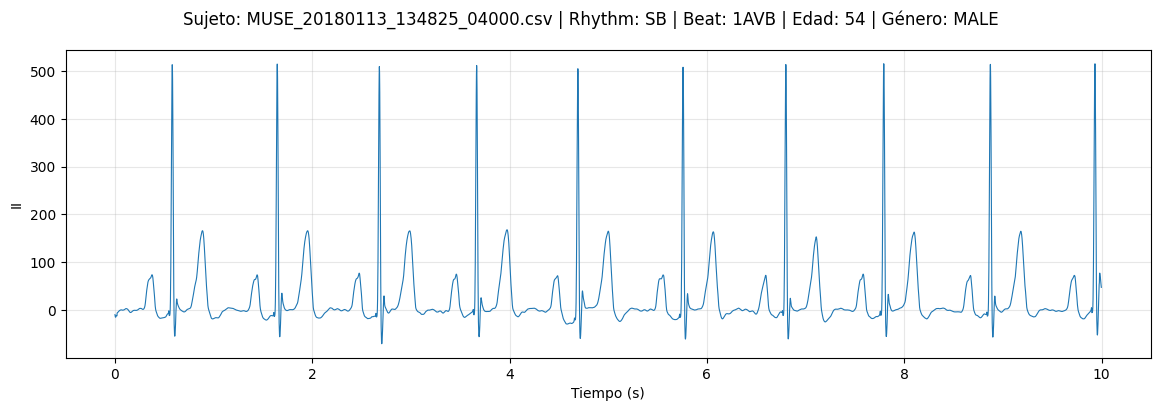

In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(t_denoised, ecg_signal_denoised["II"], linewidth=0.8)
plt.ylabel("II")
plt.xlabel("Tiempo (s)")
plt.grid(True, alpha=0.3)

plt.suptitle(
    f"Sujeto: {FILENAME} | Rhythm: {rhythm} | Beat: {beat} | "
    f"Edad: {age} | Género: {gender}",
    fontsize=12
)

Text(0.5, 0.98, 'Sujeto: MUSE_20180113_134825_04000.csv | Rhythm: SB | Beat: 1AVB | Edad: 54 | Género: MALE')

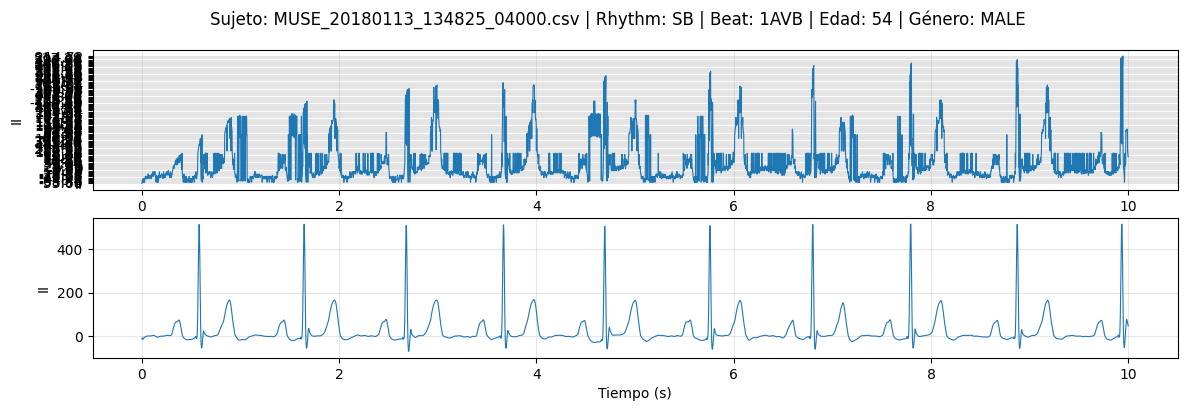

In [ ]:
plt.figure(figsize=(14, 4))
plt.subplot(211)
plt.plot(t, ecg_signal["II"], linewidth=0.8)
plt.ylabel("II")
plt.xlabel("Tiempo (s)")
plt.grid(True, alpha=0.3)
plt.subplot(212)
plt.plot(t_denoised, ecg_signal_denoised["II"], linewidth=0.8)
plt.ylabel("II")
plt.xlabel("Tiempo (s)")
plt.grid(True, alpha=0.3)

plt.suptitle(
    f"Sujeto: {FILENAME} | Rhythm: {rhythm} | Beat: {beat} | "
    f"Edad: {age} | Género: {gender}",
    fontsize=12
)

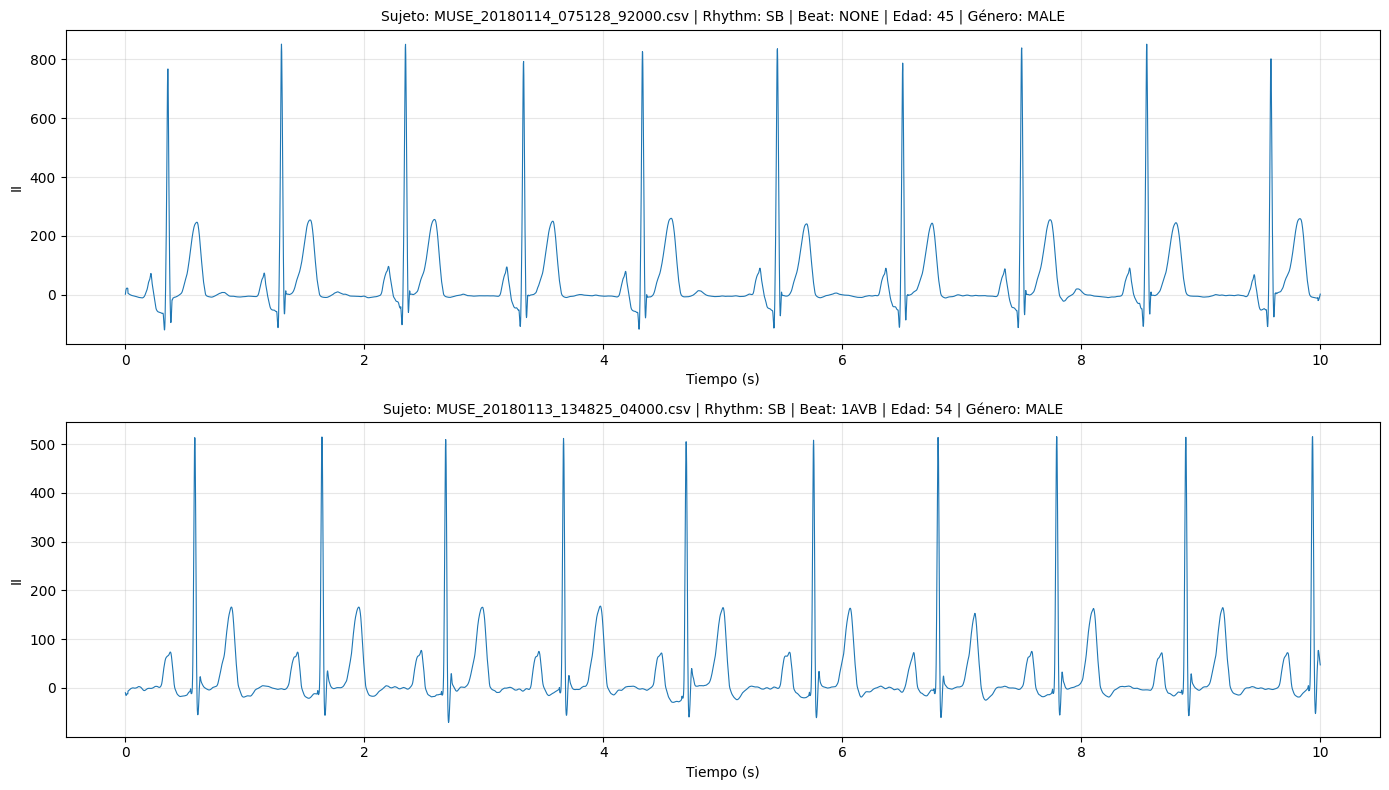

In [ ]:
subject_files = [
    "MUSE_20180114_075128_92000.csv",
    "MUSE_20180113_134825_04000.csv",
]

plt.figure(figsize=(14, 8))

for i, fname in enumerate(subject_files, start=1):
    meta = diagnostics[diagnostics["FileName"] == Path(fname).stem].reset_index(drop=True)
   
    sig = pd.read_csv(SIGNALS_DIR_DENOISED / fname, header=None, names=LEADS)
    t_sub = np.arange(len(sig)) / FS

    rhythm = meta.loc[0, "Rhythm"]
    beat = meta.loc[0, "Beat"]
    age = meta.loc[0, "PatientAge"]
    gender = meta.loc[0, "Gender"]

    plt.subplot(len(subject_files), 1, i)
    plt.plot(t_sub, sig["II"], linewidth=0.8)
    plt.ylabel("II")
    plt.xlabel("Tiempo (s)")
    plt.grid(True, alpha=0.3)
    plt.title(
        f"Sujeto: {fname} | Rhythm: {rhythm} | Beat: {beat} | "
        f"Edad: {age} | Género: {gender}",
        fontsize=10
    )

plt.tight_layout()
plt.show()